# Capstone: Ranking Pages to Review First (mirrors the deployed paper)

## 1. Question
Which pages should an editor check first because their search views are falling? Decision supported: which pages get a human review this month. A wrong pick wastes editor time or misses a slipping page. Lane: Refresh / Content Opportunity Scoring.

## 2. Data
FlyRank ML Internship starter release: 30,000 pages, 32 pseudonymized clients, one row per page, trailing 90-day metrics plus last-30 vs previous-30-day trend. The warehouse release was not used for results. Excluded: label sources (trend columns and the 30-day columns), IDs as inputs, product flags (none in the data).

In [1]:
import os, sys, subprocess
import pandas as pd
if "google.colab" in sys.modules and not os.path.isdir("data/raw"):
    if not os.path.isdir("Flyrank-MLE-intern"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/ysl21292/Flyrank-MLE-intern.git"], check=True)
    os.chdir("Flyrank-MLE-intern")
while not os.path.isdir("data/raw") and os.getcwd() != "/":
    os.chdir("..")
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
declined = (df.trend_direction == "down").astype(int)
print(f"{len(df):,} pages, {df.client_id.nunique()} clients, base rate declining: {declined.mean():.2f}")

30,000 pages, 32 clients, base rate declining: 0.54


## 3. Methodology
- Label (proxy): impressions down more than 20%, last 30 vs previous 30 days.
- Baseline rule: under 180 days old, untouched 90+ days, 100+ impressions with a position; ranked by days untouched. Reason code young_untouched_visible, action review_for_refresh.
- Models: logistic regression and random forest on observed signals; medians fill gaps inside each fold; seeds 42.
- Validation: 5-fold grouped by client; Precision@K and AUC next to the base rate.
- Leakage checks: banned columns absent; a deliberate leaky column gave AUC 1.00 and was removed. Full code: w04_baseline_score, w05_model and w06_validation_audit.

## 4. Results (vs baseline)
Mean over 5 folds of unseen clients (from the ML-08 notebook). Base rate 0.54.

In [2]:
results = pd.DataFrame({"method": ["Random picking", "Baseline rule", "Logistic regression", "Random forest"],
    "P@20": [.54, .68, .76, .80], "P@50": [.54, .74, .80, .74], "P@50 worst-best": ["", "0.44-0.92", "0.62-0.88", "0.56-0.90"],
    "P@100": [.54, .71, .81, .77], "AUC": [.50, .52, .66, .67]})
print(results.to_string(index=False))

             method  P@20  P@50 P@50 worst-best  P@100  AUC
     Random picking  0.54  0.54                   0.54 0.50
      Baseline rule  0.68  0.74       0.44-0.92   0.71 0.52
Logistic regression  0.76  0.80       0.62-0.88   0.81 0.66
      Random forest  0.80  0.74       0.56-0.90   0.77 0.67


## 5. Limitations
The label is a short-window proxy and the 90-day features overlap its window (AUC falls to 0.57-0.59 without the 90-day totals). The rule was tuned on the whole file. Flagged pages are concentrated in a few clients. Observational data: no causal claims, nothing about Google's algorithm. Results are directional decision-support.

## 6. Ranked recommendations
1. Use the list as a review queue; a person decides.
2. Review flagged pages in batches by client and last-update date.
3. Rule out seasonality, sibling pages and low-volume noise before refreshing.
4. Treat deep rankings (position 30+) and no-click pages as likely false alarms.
5. Monitor monthly on unseen clients; retrain if Precision@50 nears the base rate.
6. Next: a future-window label on the warehouse release.
Do not automate edits, deletions or traffic promises.

## 7. Artifacts the paper embeds
Figure: Precision@50 by method (saved to work/figures).

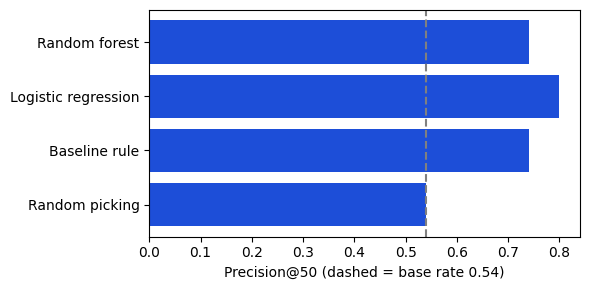

In [3]:
import matplotlib.pyplot as plt
os.makedirs("work/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(results.method, results["P@50"], color="#1d4ed8")
ax.axvline(0.54, color="gray", linestyle="--")
ax.set_xlabel("Precision@50 (dashed = base rate 0.54)")
plt.tight_layout(); plt.savefig("work/figures/p50_by_method.png", dpi=120); plt.show()

## ML-12: Tell the story
### 5-minute demo outline
1. Question (1 min): which pages should an editor check first?
2. Method (1 min): a transparent rule vs logistic regression vs random forest, tested on unseen clients.
3. One chart (1 min): Precision@50 by method against the 0.54 base rate.
4. One honest result (1 min): logistic regression 0.80 vs rule 0.74, but fold-to-fold spread is large, and a random split would have flattered the forest (0.96 vs 0.74).
5. One recommendation (1 min): review flagged pages in batches and check for seasonality first; a person decides.

### Social post
I tested whether a model beats a simple rule at picking which web pages to review first. The trap: a random split made my random forest look great (0.96 Precision@50). Holding out whole clients dropped it to 0.74. The lesson: test on groups the model has never seen, and always print the base rate next to your score.

### Employer-facing summary
I built and honestly validated a ranking system for which content pages to review first, on FlyRank's anonymized search data (30,000 pages, 32 clients). A client-held-out test showed a simple model modestly beats a transparent rule, while leakage checks showed much of the signal came from overlapping 90-day totals. The result is directional decision-support with the limits stated openly.